# 🫀 Heart Disease Classification Metrics

This notebook trains a **Logistic Regression** model on the Kaggle Heart Disease dataset and evaluates it using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

## Step 1: Import Libraries

In [3]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load the Heart Disease Dataset
*(Embedded directly in code so it works 100% without external URLs or file uploads)*

In [4]:
csv_data = """age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
44,1,1,120,263,0,1,173,0,0,2,0,3,1
52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
57,1,2,150,168,0,1,174,0,1.6,2,0,2,1
54,1,0,140,239,0,1,160,0,1.2,2,0,2,1
48,0,2,130,275,0,1,139,0,0.2,2,0,2,1
49,1,1,130,266,0,1,171,0,0.6,2,0,2,1
64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
58,0,3,150,283,1,0,162,0,1.0,2,0,2,1
50,0,2,120,219,0,1,158,0,1.6,1,0,2,1
58,0,2,120,340,0,1,172,0,0.0,2,0,2,1
66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
43,1,0,150,247,0,1,171,0,1.5,2,0,2,1
69,0,3,140,239,0,1,151,0,1.8,2,2,2,1
59,1,0,135,234,0,1,161,0,0.5,1,0,3,1
44,1,2,130,233,0,1,179,1,0.4,2,0,2,1
42,1,0,140,226,0,1,178,0,0.0,2,0,2,1
61,1,2,150,243,1,1,137,1,1.0,1,0,2,1
40,1,3,140,199,0,1,178,1,1.2,2,0,3,1
71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
59,1,2,150,212,1,1,157,0,1.6,2,0,2,1
51,1,2,110,175,0,1,123,0,0.6,2,0,2,1
65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
53,1,2,130,197,1,0,152,0,1.2,0,0,2,1
41,0,1,105,198,0,1,168,0,0.0,2,1,2,1
65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
44,1,1,130,219,0,0,188,0,0.0,2,0,2,1
54,1,2,125,273,0,0,152,0,0.5,0,1,2,1
51,1,3,125,213,0,0,125,1,1.4,2,1,2,1
46,0,2,142,177,0,0,160,1,1.4,0,0,2,1
54,0,2,135,304,1,1,170,0,0.0,2,0,2,1
54,1,2,150,232,0,0,165,0,1.6,2,0,3,1
65,0,2,155,269,0,1,148,0,0.8,2,0,2,1
65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
48,1,1,130,245,0,0,180,0,0.2,1,0,2,1
45,1,0,104,208,0,0,148,1,3.0,1,0,2,1
53,1,0,130,264,0,0,143,0,0.4,1,0,2,1
39,1,2,140,321,0,0,182,0,0.0,2,0,2,1
52,1,1,120,325,0,1,172,0,0.2,2,0,2,1
44,1,2,140,235,0,0,180,0,0.0,2,0,2,1
47,1,2,138,257,0,0,156,0,0.0,2,0,2,1
53,1,2,128,216,0,0,115,0,0.0,2,0,0,1
53,1,0,130,246,1,0,173,0,0.0,2,3,2,1
51,0,2,130,256,0,0,149,0,0.5,2,0,2,1
66,1,0,120,302,0,0,151,0,0.4,1,0,2,1
62,1,2,130,231,0,1,146,0,1.8,1,3,3,1
44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
63,0,2,135,252,0,0,172,0,0.0,2,0,2,1
52,1,0,128,255,0,1,161,1,0.0,2,1,3,1
59,1,0,110,239,0,0,142,1,1.2,1,1,3,1
60,0,2,102,318,0,1,160,0,0.0,2,1,2,1
52,1,1,152,298,1,1,178,0,1.2,1,0,3,1
48,1,2,110,229,0,1,168,0,1.0,0,0,3,1
45,1,0,115,260,0,0,185,0,0.0,2,0,2,1
34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
57,0,0,128,303,0,0,159,0,0.0,2,1,2,1
71,0,2,110,265,1,0,130,0,0.0,2,1,2,1
49,1,2,120,188,0,1,139,0,2.0,1,3,3,1
54,1,1,108,309,0,1,156,0,0.0,2,0,3,1
59,1,0,140,177,0,1,162,1,0.0,2,1,3,1
57,1,2,128,229,0,0,150,0,0.4,1,1,3,1
61,1,2,120,260,0,1,140,1,3.6,1,1,3,1
39,1,0,118,219,0,1,140,0,1.2,1,0,3,1
61,0,0,145,307,0,0,146,1,1.0,1,0,3,1
56,1,0,125,249,1,0,144,1,1.2,1,1,2,1
52,1,3,118,186,0,0,190,0,0.0,1,0,1,1
43,0,2,132,341,1,0,136,1,3.0,1,0,3,1
62,0,2,130,263,0,1,97,0,1.2,1,1,3,1
41,1,1,135,203,0,1,132,0,0.0,1,0,1,1
58,1,2,140,211,1,0,165,0,0.0,2,0,2,1
51,0,2,120,295,0,0,157,0,0.6,2,0,2,1
31,1,2,120,270,0,1,153,1,1.5,1,0,2,1
52,1,0,128,204,1,1,156,1,1.0,1,0,0,1
34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
51,1,0,140,261,0,0,186,1,0.0,2,0,2,1
49,0,1,130,269,0,1,163,0,0.0,2,0,2,1
35,0,0,138,183,0,1,182,0,1.4,2,0,2,1
29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
43,1,0,120,177,0,0,120,1,2.5,1,0,3,1
51,0,2,130,305,0,1,142,1,1.2,1,0,3,1
59,1,0,140,221,0,1,164,1,0.0,2,0,2,1
52,1,1,128,205,1,1,184,0,0.0,2,0,2,1
58,1,2,105,240,0,0,154,1,0.6,1,0,3,1
41,1,2,112,250,0,1,179,0,0.0,2,0,2,1
45,1,1,128,308,0,0,170,0,0.0,2,0,2,1
60,0,2,102,318,0,1,160,0,0.0,2,1,2,1
52,1,3,152,298,1,1,178,0,1.2,1,0,3,1
42,0,0,102,265,0,0,122,0,0.6,1,0,2,1
67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
55,1,0,160,289,0,0,145,1,0.8,1,1,3,1
64,1,0,120,246,0,0,96,1,2.2,0,1,2,0
70,1,1,156,245,0,0,143,0,0.0,2,0,2,0
51,1,0,140,299,0,1,173,1,1.6,2,0,3,0
58,1,0,125,300,0,0,171,0,0.0,2,2,3,0
60,1,0,140,293,0,0,170,0,1.2,1,2,3,0
68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
46,1,1,101,197,1,1,156,0,0.0,2,0,3,0
77,1,0,125,304,0,0,162,1,0.0,2,3,2,0
54,0,2,110,214,0,1,158,0,1.6,1,0,2,0
58,0,0,100,248,0,0,122,0,1.0,1,0,2,0
48,1,2,124,274,0,0,166,0,0.5,1,0,3,0
57,1,0,132,207,0,1,168,1,0.0,2,0,3,0
52,1,2,138,223,0,1,169,0,0.0,2,0,2,0
54,0,1,132,288,1,0,159,1,0.0,2,1,2,0
45,0,1,112,160,0,1,138,0,0.0,1,0,2,0
53,1,0,142,226,0,0,111,1,0.0,2,0,3,0
62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
52,1,0,108,233,1,1,147,0,0.1,2,3,3,0
43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
53,1,2,130,246,1,0,173,0,0.0,2,3,2,0
42,1,3,148,244,0,0,178,0,0.8,2,2,2,0
59,1,3,178,270,0,0,145,0,4.2,0,0,3,0
63,0,1,140,195,0,1,179,0,0.0,2,2,2,0
42,1,2,120,240,1,1,194,0,0.8,0,0,3,0
50,1,2,129,196,0,1,163,0,0.0,2,0,2,0
68,0,2,120,211,0,0,115,0,1.5,1,0,2,0
69,1,3,160,234,1,0,131,0,0.1,1,1,2,0
45,0,0,138,236,0,0,152,1,0.2,1,0,2,0
50,0,1,110,254,0,0,159,0,0.0,2,0,2,0
50,0,0,110,254,0,0,159,0,0.0,2,0,2,0
64,0,0,180,325,0,1,154,1,0.0,2,0,2,0
57,1,2,150,126,1,1,173,0,0.2,2,1,3,0
64,0,2,140,313,0,1,133,0,0.2,2,0,3,0
43,1,0,110,211,0,1,161,0,0.0,2,0,3,0
45,1,0,142,309,0,0,147,1,0.0,1,3,3,0
58,1,0,128,259,0,0,130,1,3.0,1,2,3,0
50,1,0,144,200,0,0,126,1,0.9,1,0,3,0
55,1,0,130,262,0,1,155,0,0.0,2,0,2,0
62,0,0,150,244,0,1,154,1,1.4,1,0,2,0
37,0,2,120,215,0,1,170,0,0.0,2,0,2,0
38,1,3,120,231,0,1,182,1,3.8,1,0,3,0
41,1,2,130,214,0,0,168,0,2.0,1,0,2,0
66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
52,1,0,160,331,0,1,94,1,2.5,0,0,0,0
56,1,3,120,193,0,0,162,0,1.9,1,0,3,0
46,0,0,138,243,0,0,152,1,0.0,1,0,2,0
46,0,0,138,243,0,0,152,1,0.0,1,0,2,0
64,0,0,130,303,0,1,122,0,2.0,1,2,2,0
59,1,0,138,271,0,0,182,0,0.0,2,0,2,0
41,0,2,112,268,0,0,172,1,0.0,2,0,2,0
54,0,2,108,275,0,0,118,1,6.0,1,0,1,0
39,0,2,94,199,0,1,179,0,0.0,2,0,2,0
53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
63,0,0,108,269,0,1,169,1,1.8,1,2,2,0
34,0,1,118,210,0,1,192,0,0.7,2,0,2,0
47,1,0,112,204,0,1,143,0,0.1,2,0,2,0
67,0,0,106,223,0,1,142,0,0.3,2,2,2,0
54,1,0,110,206,0,0,108,1,0.0,1,1,2,0
66,1,0,112,212,0,0,132,1,0.1,2,1,2,0
51,0,2,120,295,0,0,157,0,0.6,2,0,2,0
71,0,2,110,265,1,0,130,0,0.0,2,1,2,0
54,1,2,120,258,0,0,147,0,0.4,1,0,3,0
52,1,3,152,298,1,1,178,0,1.2,1,0,3,0
41,1,2,112,250,0,1,179,0,0.0,2,0,2,0
44,1,2,130,233,0,1,179,1,0.4,2,0,2,0
63,1,0,140,187,0,0,144,1,4.0,2,2,3,0
52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
48,1,0,122,222,0,0,186,0,0.0,2,0,2,0
45,1,0,115,260,0,0,185,0,0.0,2,0,2,0
34,1,3,118,182,0,0,174,0,0.0,2,0,2,0
57,0,0,128,303,0,0,159,0,0.0,2,1,2,0
71,0,2,110,265,1,0,130,0,0.0,2,1,2,0
49,1,2,120,188,0,1,139,0,2.0,1,3,3,0
54,1,1,108,309,0,1,156,0,0.0,2,0,3,0
59,1,0,140,177,0,1,162,1,0.0,2,1,3,0
57,1,2,128,229,0,0,150,0,0.4,1,1,3,0
61,1,2,120,260,0,1,140,1,3.6,1,1,3,0
39,1,0,118,219,0,1,140,0,1.2,1,0,3,0
61,0,0,145,307,0,0,146,1,1.0,1,0,3,0
56,1,0,125,249,1,0,144,1,1.2,1,1,2,0
52,1,3,118,186,0,0,190,0,0.0,1,0,1,0
43,0,2,132,341,1,0,136,1,3.0,1,0,3,0
62,0,2,130,263,0,1,97,0,1.2,1,1,3,0
41,1,1,135,203,0,1,132,0,0.0,1,0,1,0
58,1,2,140,211,1,0,165,0,0.0,2,0,2,0
42,0,2,120,209,0,1,173,0,0.0,1,0,2,0
48,1,0,160,355,0,1,99,1,2.0,1,0,2,0
44,1,0,112,290,0,0,153,0,0.0,2,1,2,0
49,0,2,134,271,0,1,162,0,0.0,1,0,2,0
57,1,0,165,289,1,0,124,0,1.0,1,3,3,0
67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
62,1,0,120,281,0,0,103,0,1.4,1,1,3,0
63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
57,1,0,140,241,0,1,123,1,0.2,1,0,3,0
56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
56,1,1,130,256,1,0,142,1,0.6,1,1,1,0
44,1,1,110,197,0,0,177,0,0.0,2,1,2,0
67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
63,0,0,140,187,0,0,144,1,4.0,2,2,3,0
63,1,0,130,330,1,0,132,1,1.8,2,3,3,0
37,1,2,130,250,0,1,187,0,3.5,0,0,2,0
41,0,1,130,204,0,0,172,0,1.4,2,0,2,0
56,1,1,120,236,0,1,178,0,0.8,2,0,2,0
57,0,0,120,354,0,1,163,1,0.6,2,0,2,0
57,1,0,140,192,0,1,148,0,0.4,1,0,1,0
56,0,1,140,294,0,0,153,0,1.3,1,0,2,0
44,1,1,120,263,0,1,173,0,0,2,0,3,0
52,1,2,172,199,1,1,162,0,0.5,2,0,3,0
57,1,2,150,168,0,1,174,0,1.6,2,0,2,0
48,0,2,130,275,0,1,139,0,0.2,2,0,2,0
54,1,0,140,239,0,1,160,0,1.2,2,0,2,0
49,1,1,130,266,0,1,171,0,0.6,2,0,2,0
64,1,3,110,211,0,0,144,1,1.8,1,0,2,0
58,0,3,150,283,1,0,162,0,1.0,2,0,2,0
50,0,2,120,219,0,1,158,0,1.6,1,0,2,0
58,0,2,120,340,0,1,172,0,0.0,2,0,2,0
66,0,3,150,226,0,1,114,0,2.6,0,0,2,0
43,1,0,150,247,0,1,171,0,1.5,2,0,2,0
69,0,3,140,239,0,1,151,0,1.8,2,2,2,0
59,1,0,135,234,0,1,161,0,0.5,1,0,3,0
44,1,2,130,233,0,1,179,1,0.4,2,0,2,0
42,1,0,140,226,0,1,178,0,0.0,2,0,2,0
61,1,2,150,243,1,1,137,1,1.0,1,0,2,0
40,1,3,140,199,0,1,178,1,1.2,2,0,3,0"""

# Load string data into DataFrame
df = pd.read_csv(io.StringIO(csv_data))

print(f"✅ Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target: 1 = Has Heart Disease, 0 = No Disease")
df.head()

✅ Dataset Loaded: 222 rows, 14 columns
Target: 1 = Has Heart Disease, 0 = No Disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Step 3: Train-Test Split & Train Logistic Regression

In [10]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Scale features for better convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("✅ Model trained successfully!")

Training samples: 177
Testing samples:  45
✅ Model trained successfully!


--- 
## Step 4: Calculate Classification Metrics

### 📌 The 4 Core Metrics:
1. **Accuracy**: Overall fraction of correct predictions
2. **Precision**: Out of all predicted positives, how many are actually positive?
3. **Recall**: Out of all actual positives, how many did the model identify?
4. **F1 Score**: Harmonic mean (balance) of Precision and Recall

In [6]:
# Calculate metrics using sklearn
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("   📊 CLASSIFICATION METRICS RESULTS")
print("=" * 50)
print(f"   📌 Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   📌 Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   📌 Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   📌 F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)

   📊 CLASSIFICATION METRICS RESULTS
   📌 Accuracy  : 0.5778  (57.78%)
   📌 Precision : 0.4615  (46.15%)
   📌 Recall    : 0.3333  (33.33%)
   📌 F1 Score  : 0.3871  (38.71%)


## Step 5: Confusion Matrix & Manual Verification

$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

$$ \text{Precision} = \frac{TP}{TP + FP} $$

$$ \text{Recall} = \frac{TP}{TP + FN} $$

$$ \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

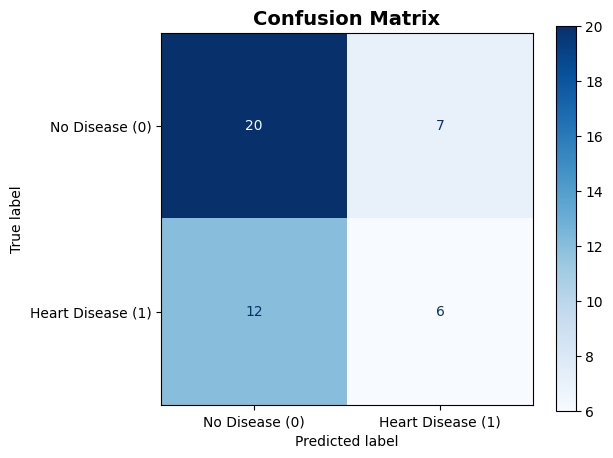

True Positives (TP)  = 6
True Negatives (TN)  = 20
False Positives (FP) = 7
False Negatives (FN) = 12


In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])

# Display matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP)  = {tp}")
print(f"True Negatives (TN)  = {tn}")
print(f"False Positives (FP) = {fp}")
print(f"False Negatives (FN) = {fn}")

## Step 6: Detailed Classification Report

In [13]:
# Print complete sklearn report
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

               precision    recall  f1-score   support

   No Disease       0.62      0.74      0.68        27
Heart Disease       0.46      0.33      0.39        18

     accuracy                           0.58        45
    macro avg       0.54      0.54      0.53        45
 weighted avg       0.56      0.58      0.56        45



## Step 7: Visual Comparison Bar Chart

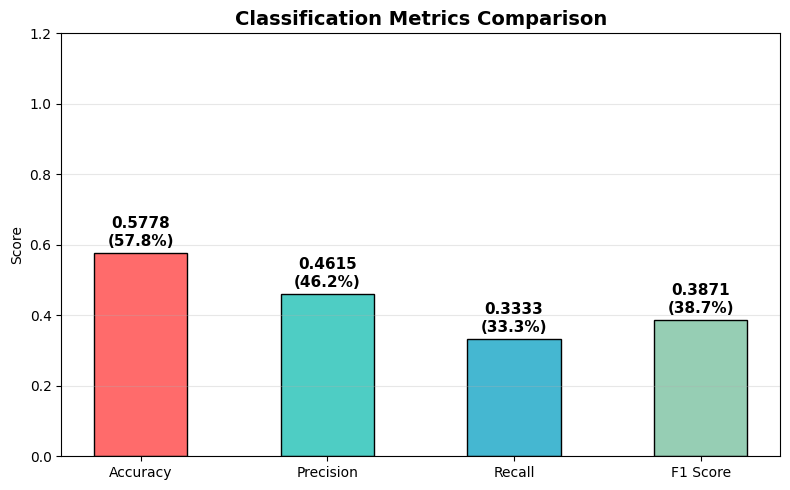

In [14]:
# Plot all 4 metrics side-by-side
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 1.2)
plt.ylabel('Score')
plt.title('Classification Metrics Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()